<a href="https://colab.research.google.com/github/noor-gh06/Cybercrime-DataMining/blob/main/Copy_of_phase3copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cybercrime Data Mining Project - phase 3

In [ ]:
# Upload the dataset file from the local device to Google Colab
from google.colab import files
uploaded = files.upload()

Saving Preprocessed_dataset.csv to Preprocessed_dataset (3).csv


### Data Loading and Preparation

In this step, the required libraries were imported, and the preprocessed dataset from Phase 2 was loaded into the environment.

The dataset was then inspected by displaying the first few rows to verify that it was loaded correctly and to gain an initial understanding of its structure, including the feature names and data types.

This step is important to ensure that the dataset is properly prepared before applying any machine learning models, and that no issues exist in the data format that could affect the analysis.

In [ ]:
# Import required libraries for data handling and model preparation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# Load the preprocessed dataset from Phase 2
df_phase3 = pd.read_csv("Preprocessed_dataset.csv")
# Display the first few rows to verify the dataset structure
df_phase3.head()

,outcome,data_compromised_GB,attack_duration_min,attack_severity,response_time_min,year,month,hour,attack_type_Brute Force,attack_type_Cross-Site Scripting,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Retail,industry_Technology,mitigation_method_Block IP,mitigation_method_Containment,mitigation_method_Patch,mitigation_method_Quarantine,mitigation_method_Reset Credentials
0,Failure,-1.205448,1.717105,-1.219286,1.416923,2024,4,11,False,False,...,False,False,False,False,False,False,True,False,False,False
1,Success,0.519862,1.048385,1.568458,-0.509669,2024,2,20,False,False,...,False,False,False,True,False,False,False,False,False,True
2,Success,-0.037204,-0.358233,0.523054,-0.066553,2024,7,18,False,False,...,False,False,False,False,False,False,False,False,True,False
3,Failure,-1.171455,1.555690,-0.870818,-1.299572,2023,12,0,False,False,...,False,True,False,False,False,False,False,True,False,False
4,Failure,1.304125,-1.695674,0.174586,0.742616,2024,7,5,False,False,...,False,False,False,False,False,False,True,False,False,False


The dataset was successfully loaded, and the preview confirms that the structure is consistent with the preprocessing performed in Phase 2.

To further ensure data quality, the dataset was previously cleaned during Phase 2, where missing values were handled, categorical variables were encoded, and numerical features were scaled. Therefore, the data is now suitable for applying machine learning models without additional preprocessing.

### Dataset Structure Inspection
In this step, the structure of the dataset was examined by displaying its shape and column names.
This helps in understanding the size of the dataset in terms of the number of records and features, which is important before applying any data mining techniques.

Knowing the dataset size also provides an initial indication of whether the data is sufficient for training machine learning models

In [ ]:
# Display dataset shape and columns
print("Shape of final dataset:", df_phase3.shape)
print("\nColumns:")
print(df_phase3.columns.tolist())

Shape of final dataset: (100000, 59)

Columns:
['outcome', 'data_compromised_GB', 'attack_duration_min', 'attack_severity', 'response_time_min', 'year', 'month', 'hour', 'attack_type_Brute Force', 'attack_type_Cross-Site Scripting', 'attack_type_DDoS', 'attack_type_Malware', 'attack_type_Phishing', 'attack_type_Ransomware', 'attack_type_SQL Injection', 'attack_type_Zero-Day Exploit', 'target_system_API', 'target_system_Cloud Service', 'target_system_Database', 'target_system_Email Server', 'target_system_IoT Device', 'target_system_Network Switch', 'target_system_User Account', 'target_system_Web Server', 'security_tools_used_Antivirus', 'security_tools_used_Endpoint Detection', 'security_tools_used_Firewall', 'security_tools_used_IDS', 'security_tools_used_MFA', 'security_tools_used_SIEM', 'security_tools_used_VPN', 'security_tools_used_WAF', 'user_role_Admin', 'user_role_Contractor', 'user_role_Employee', 'user_role_External User', 'location_Australia', 'location_Brazil', 'location_C

The dataset shape and column names were displayed to understand its structure.

The dataset contains a large number of records and multiple features, which makes it suitable for applying both classification and clustering techniques.

Having multiple features allows the model to capture different characteristics of cybercrime incidents. However, the actual impact of each feature on prediction performance will be evaluated later during the modeling phase.

### Feature Selection and Target Definition
In this step, the dataset was divided into input features (X) and the target variable (y).
The target variable is outcome, which will be used in the classification task, while the remaining attributes are used as input features.

Additionally, the class distribution of the target variable was examined to understand whether the dataset is balanced or imbalanced. This is a critical step, as class imbalance can significantly affect the performance of classification models..

In [ ]:
# Separate features and target variable
X = df_phase3.drop("outcome", axis=1)
y = df_phase3["outcome"]
# Display shapes and class distribution
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (100000, 58)
y shape: (100000,)

Class distribution:
outcome
Success    50030
Failure    49970
Name: count, dtype: int64


The dataset was successfully divided into input features (X) and the target variable (y), where "outcome" represents the class label for the classification task.

The class distribution shows that the dataset is balanced, as both classes (Success and Failure) have a similar number of records.

This indicates that the classification model is not biased toward a specific class, and therefore, class imbalance is unlikely to be the main reason for the low performance observed in the model.

### Data Preparation for Clustering
In this step, the dataset was prepared for clustering by removing the target variable (outcome), since clustering is an unsupervised learning technique that does not rely on labeled data.

Only the feature set was retained to allow the clustering algorithm to group similar records based on their inherent characteristics rather than predefined classes

In [ ]:
# Prepare data for clustering by removing the target variable
X_clustering = df_phase3.drop("outcome", axis=1)
# Display shape of clustering data
print("Clustering data shape:", X_clustering.shape)

Clustering data shape: (100000, 58)


The dataset was prepared for clustering by removing the target variable (outcome), since clustering is an unsupervised learning technique that does not use labeled data.

The resulting dataset contains only the input features, allowing the algorithm to group similar records based on their inherent characteristics.

It is important to note that the same feature set used in the classification task is reused here (without the target variable), ensuring consistency between both approaches while focusing only on feature relationships.

### Train-Test Split (90/10)
In this step, the dataset was split into training and testing sets using a 90/10 ratio.
The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data.

A higher proportion of training data (90%) allows the model to learn more patterns from the dataset, which may improve its performance, especially when dealing with complex data such as cybercrime incidents.

Stratified sampling was applied to preserve the class distribution in both training and testing sets. This is important to ensure that the evaluation is fair and not biased due to uneven class representation.

In [ ]:
# Split dataset into training and testing sets (90/10)
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)
# Display shapes of the split datasets
print("90/10 split:")
print("X_train_90:", X_train_90.shape)
print("X_test_10 :", X_test_10.shape)
print("y_train_90:", y_train_90.shape)
print("y_test_10 :", y_test_10.shape)

90/10 split:
X_train_90: (90000, 58)
X_test_10 : (10000, 58)
y_train_90: (90000,)
y_test_10 : (10000,)


The dataset was split into training and testing sets using a 90/10 ratio. The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data.

A larger training size (90%) allows the model to learn more patterns from the data.

Stratified sampling was applied to preserve the class distribution in both training and testing sets, ensuring a fair and unbiased evaluation.

### Train-Test Split (80/20)


In this step, the dataset was split into training and testing sets using an 80/20 ratio.
Compared to the previous 90/10 split, this configuration allocates more data for testing, which allows for a more reliable and stable evaluation of the model’s performance.

However, reducing the size of the training set may slightly limit the model’s ability to learn complex patterns from the data.

Stratified sampling was applied to ensure that the class distribution remains consistent across both training and testing sets, maintaining fairness in evaluation.

In [ ]:
# Split dataset into training and testing sets (80/20)
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# Display shapes of the split datasets
print("80/20 split:")
print("X_train_80:", X_train_80.shape)
print("X_test_20 :", X_test_20.shape)
print("y_train_80:", y_train_80.shape)
print("y_test_20 :", y_test_20.shape)

80/20 split:
X_train_80: (80000, 58)
X_test_20 : (20000, 58)
y_train_80: (80000,)
y_test_20 : (20000,)


The dataset was split into training and testing sets using an 80/20 ratio. In this split, 80% of the data is used for training, while 20% is used for testing.

Compared to the 90/10 split, this configuration provides a larger testing set, which can give a more reliable evaluation of model performance.

Stratified sampling was applied to preserve the class distribution in both sets, ensuring that the training and testing data remain representative of the original dataset.

### Train-Test Split (70/30)

In this step, the dataset was split into training and testing sets using a 70/30 ratio.
This configuration allocates the largest portion of data for testing among all splits, which allows for a more robust and reliable evaluation of the model’s generalization performance.

However, reducing the training data to 70% may limit the model’s ability to learn complex patterns, especially in datasets with high variability such as cybercrime data.

Stratified sampling was applied to preserve the class distribution in both sets, ensuring that the evaluation remains fair and representative.

In [ ]:
# Split dataset into training and testing sets (70/30)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
# Display shapes of the split datasets
print("70/30 split:")
print("X_train_70:", X_train_70.shape)
print("X_test_30 :", X_test_30.shape)
print("y_train_70:", y_train_70.shape)
print("y_test_30 :", y_test_30.shape)

70/30 split:
X_train_70: (70000, 58)
X_test_30 : (30000, 58)
y_train_70: (70000,)
y_test_30 : (30000,)


The dataset was split into training and testing sets using a 70/30 ratio. In this configuration, a larger portion of the data is reserved for testing, which can provide a more reliable evaluation of the model’s ability to generalize to unseen data.

However, reducing the training data to 70% may limit the model’s ability to learn complex patterns.

Stratified sampling was applied to preserve the class distribution in both sets, ensuring that the evaluation remains fair and representative of the original dataset.

### Importing Libraries for Classification

In this step, the required libraries for Decision Tree classification were imported.

These libraries are used to build the classification model, evaluate its performance using accuracy and confusion matrix, and visualize the structure of the decision tree to better understand how the model makes

In [ ]:
# Import libraries for Decision Tree model and evaluation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

In this step, the required libraries for Decision Tree classification were imported.

These libraries are used to build the classification model, evaluate its performance using metrics such as accuracy, precision, sensitivity, specificity, and confusion matrix, and visualize the structure of the decision tree to better understand how the model makes predictions.

### Decision Tree Training (90/10 - Gini)

In this step, a Decision Tree classifier was trained using the Gini Index as the splitting criterion on the 90/10 dataset split.

The model learns patterns from the training data by recursively splitting the features based on impurity reduction, aiming to create homogeneous groups of the target variable (outcome).

Using the Gini Index allows the model to select splits that minimize class impurity, which helps in building an efficient decision structure.

In [ ]:
#Model Training (90/10 Split)
#Trains Decision Tree using Gini on 90/10 split
model_90 = DecisionTreeClassifier(criterion='gini')
model_90.fit(X_train_90, y_train_90)

DecisionTreeClassifier()

In this step, a Decision Tree classifier was trained using the Gini Index as the splitting criterion on the 90/10 dataset split.

The model learns patterns from the training data by recursively splitting features based on impurity reduction, aiming to create homogeneous groups of the target variable (outcome).

Using the Gini Index allows the model to select splits that minimize class impurity and build an efficient decision structure.

The model has been successfully trained and is now ready for evaluation. It is important to note that Decision Trees can be prone to overfitting if not properly controlled, as they may create very complex structures that fit the training data too closely.

### Prediction (90/10 Split)

In this step, the trained Decision Tree model was used to generate predictions on the testing dataset.

This step is essential to evaluate how well the model generalizes to unseen data, as the test set was not used during training.

The predicted values will later be compared with the actual target values to assess the model’s performance using evaluation metrics such as accuracy and confusion matrix.

In [ ]:
# Make predictions using the trained model on test data
y_pred_90 = model_90.predict(X_test_10)

In this step, the trained Decision Tree model was used to generate predictions on the testing dataset.

This step is essential to evaluate how well the model generalizes to unseen data, since the test set was not used during training.

The predicted values are stored and will be compared with the actual target values in the next step to evaluate the model’s performance using metrics such as accuracy, precision, sensitivity, specificity, and confusion matrix.

### Model Evaluation - Accuracy (90/10)

In this step, the accuracy of the Decision Tree model was calculated using the testing dataset.

Accuracy represents the proportion of correctly predicted instances out of the total predictions, providing a general measure of model performance.

However, accuracy alone may not fully reflect the model’s effectiveness, especially if the dataset is imbalanced, as the model may achieve a reasonable accuracy by favoring the majority class.

In [ ]:
# Calculate accuracy of the model

# Prediction
y_pred_90 = model_90.predict(X_test_10)

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

acc_90 = accuracy_score(y_test_10, y_pred_90)

precision_90 = precision_score(y_test_10, y_pred_90, pos_label='Success')
sensitivity_90 = recall_score(y_test_10, y_pred_90, pos_label='Success')

tn, fp, fn, tp = confusion_matrix(
    y_test_10,
    y_pred_90,
    labels=['Failure', 'Success']
).ravel()

specificity_90 = tn / (tn + fp)

print("Evaluation Metrics (90/10 - Gini)")
print("Accuracy:", acc_90)
print("Precision:", precision_90)
print("Sensitivity:", sensitivity_90)
print("Specificity:", specificity_90)

Evaluation Metrics (90/10 - Gini)
Accuracy: 0.5026
Precision: 0.5029525554876807
Sensitivity: 0.49370377773336
Specificity: 0.5115069041424855


The obtained accuracy is approximately 0.50, which indicates that the model has very limited predictive performance and is performing close to random guessing.

This suggests that the model is not effectively capturing meaningful relationships between the input features and the target variable.

Possible reasons for this behavior include the presence of weak or non-informative features, or complex patterns in the dataset that are not well handled by a Decision Tree model.

Since the dataset is balanced, random guessing would result in an accuracy close to 50%, which aligns with the observed results. This confirms that the model is not learning useful patterns from the data.

Therefore, additional evaluation metrics such as precision, sensitivity, and specificity are important to provide a deeper understanding of the model’s behavior.

### Confusion Matrix (90/10)

In this step, the confusion matrix was used to evaluate the performance of the Decision Tree model in more detail.

The confusion matrix provides a breakdown of predictions by showing the number of correctly and incorrectly classified instances for each class. This allows for a deeper understanding of how the model performs across different classes.

Unlike accuracy, which gives an overall measure, the confusion matrix reveals whether the model is biased toward a particular class or struggles to correctly classify certain categories.

In [ ]:
# Generate confusion matrix
cm_90 = confusion_matrix(y_test_10, y_pred_90)
print("Confusion Matrix (90/10):\n", cm_90)

Confusion Matrix (90/10):
 [[2556 2441]
 [2533 2470]]


The confusion matrix shows that the number of correct and incorrect predictions is very similar across both classes.

The values of true positives and false negatives, as well as true negatives and false positives, are close to each other, indicating that the model struggles to distinguish between the two classes.

This behavior confirms the earlier observation that the model is performing close to random guessing.

Since the dataset is balanced, there is no clear bias toward a specific class. Instead, the model fails to capture meaningful patterns that differentiate between Success and Failure.

### Decision Tree Visualization (90/10)

In this step, the trained Decision Tree model was visualized to better understand how it makes decisions.

The tree structure illustrates how different features are used to split the data into smaller subsets, leading to final predictions. Each node represents a decision based on a feature, and the branches represent possible outcomes.

The tree depth was limited to improve readability and focus on the most important decision rules, although this does not fully represent the complete complexity of the model.

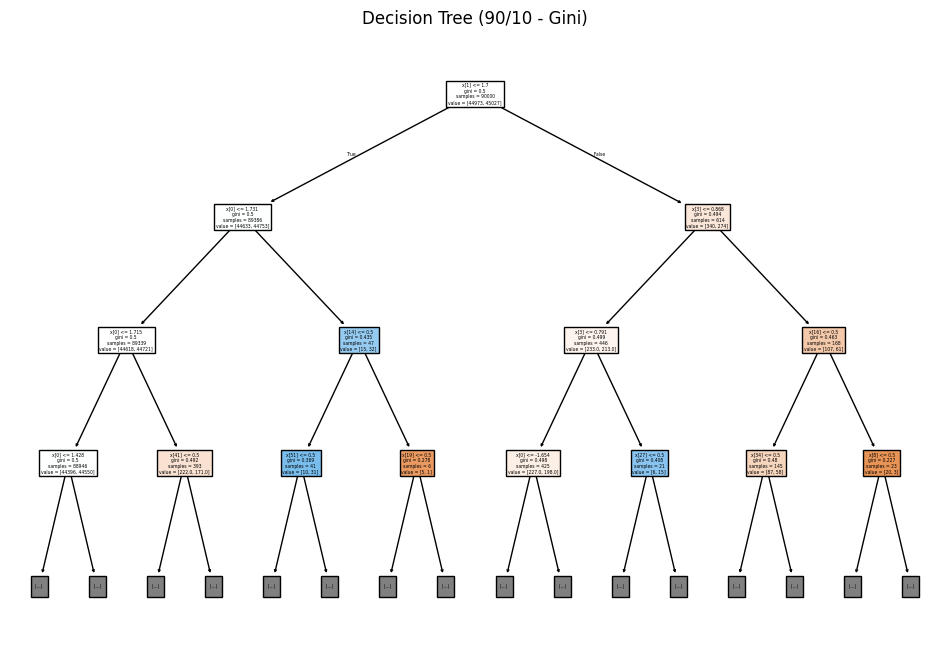

In [ ]:
# Visualize the Decision Tree model
plt.figure(figsize=(12,8))
plot_tree(model_90, filled=True, max_depth=3)
plt.title("Decision Tree (90/10 - Gini)")
plt.show()

The visualization of the Decision Tree provides insight into how the model makes decisions based on feature splits.

The upper levels of the tree show the most influential features used for splitting the data. However, the tree does not show clear separation between the classes, as both classes still appear in many nodes.

This indicates that the model is not able to find strong decision boundaries between the classes, which explains the low accuracy observed earlier.

Although the tree structure is relatively simple (due to depth limitation), it reflects the difficulty of the dataset rather than the complexity of the model.

### Decision Tree (80/20 - Gini)

In this step, the Decision Tree model was trained and evaluated using the 80/20 data split with the Gini Index as the splitting criterion.

The model was trained on the training set and then evaluated on the testing set using accuracy and confusion matrix. The tree was also visualized to better understand the decision-making process.

This configuration provides a more balanced evaluation compared to the 90/10 split, as a larger test set allows for a more reliable assessment of model performance.

Evaluation Metrics (80/20 - Gini)
Accuracy: 0.4994
Precision: 0.4997044917257683
Sensitivity: 0.5069958025184889
Specificity: 0.4917950770462277
Confusion Matrix (80/20 - Gini):
 [[4915 5079]
 [4933 5073]]


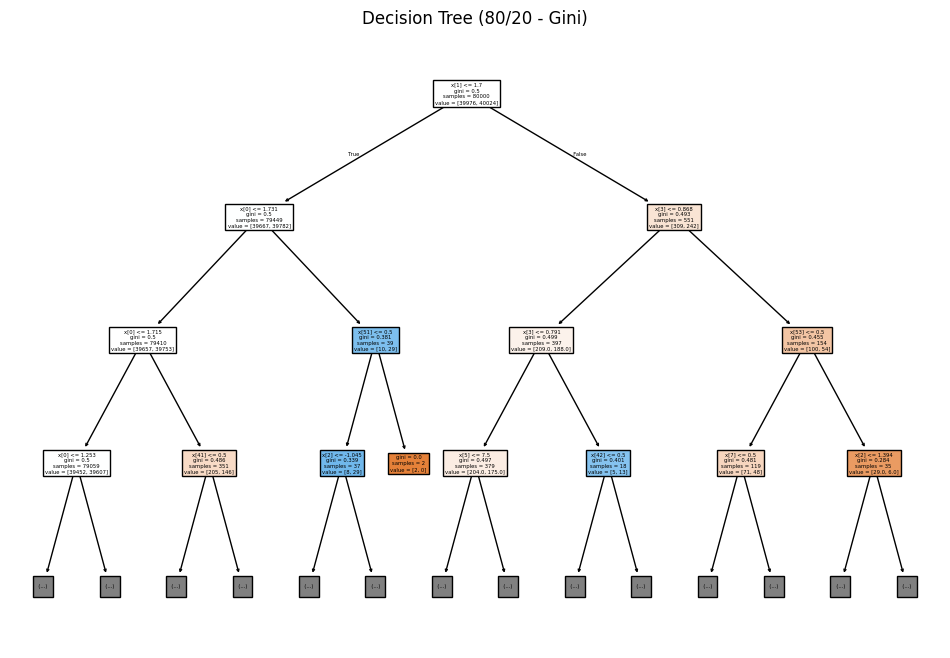

In [ ]:
# Train, predict, evaluate, and visualize Decision Tree (80/20 - Gini)
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

model_80 = DecisionTreeClassifier(criterion='gini')
model_80.fit(X_train_80, y_train_80)

# Prediction
y_pred_80 = model_80.predict(X_test_20)

# Evaluation Metrics
acc_80 = accuracy_score(y_test_20, y_pred_80)

precision_80 = precision_score(y_test_20, y_pred_80, pos_label='Success')
sensitivity_80 = recall_score(y_test_20, y_pred_80, pos_label='Success')

tn, fp, fn, tp = confusion_matrix(
    y_test_20,
    y_pred_80,
    labels=['Failure', 'Success']
).ravel()

specificity_80 = tn / (tn + fp)

print("Evaluation Metrics (80/20 - Gini)")
print("Accuracy:", acc_80)
print("Precision:", precision_80)
print("Sensitivity:", sensitivity_80)
print("Specificity:", specificity_80)

# Confusion Matrix
cm_80 = confusion_matrix(y_test_20, y_pred_80, labels=['Failure', 'Success'])
print("Confusion Matrix (80/20 - Gini):\n", cm_80)

# Decision Tree Visualization
plt.figure(figsize=(12,8))
plot_tree(model_80, filled=True, max_depth=3)
plt.title("Decision Tree (80/20 - Gini)")
plt.show()

The obtained accuracy is approximately 0.50, which is very similar to the results observed in the 90/10 split.

All evaluation metrics (accuracy, precision, sensitivity, and specificity) remain close to 0.5, indicating that the model is performing close to random guessing.

This consistency across different splits suggests that increasing the size of the testing data does not improve the model’s predictive performance.

The confusion matrix further confirms this behavior, as the number of correct and incorrect predictions is nearly equal for both classes.

Therefore, the limitation does not appear to be related to the data split, but rather to the dataset itself, where the features may not provide strong discriminatory power for the target variable.

Overall, the model demonstrates stable but weak performance across different configurations.

### Decision Tree (70/30 - Gini)

In this step, the Decision Tree model was trained and evaluated using the 70/30 data split with the Gini Index.

This configuration uses the largest testing set among all splits, which allows for a more robust evaluation of the model’s generalization ability. However, reducing the training data may limit the model’s capacity to learn complex patterns.

The model was evaluated using accuracy and confusion matrix, and the tree was visualized to understand its structure.

Evaluation Metrics (70/30 - Gini)
Accuracy: 0.4947666666666667
Precision: 0.4950521529820808
Sensitivity: 0.4933040175894463
Specificity: 0.4962310719765192
Confusion Matrix (70/30 - Gini):
 [[7439 7552]
 [7605 7404]]


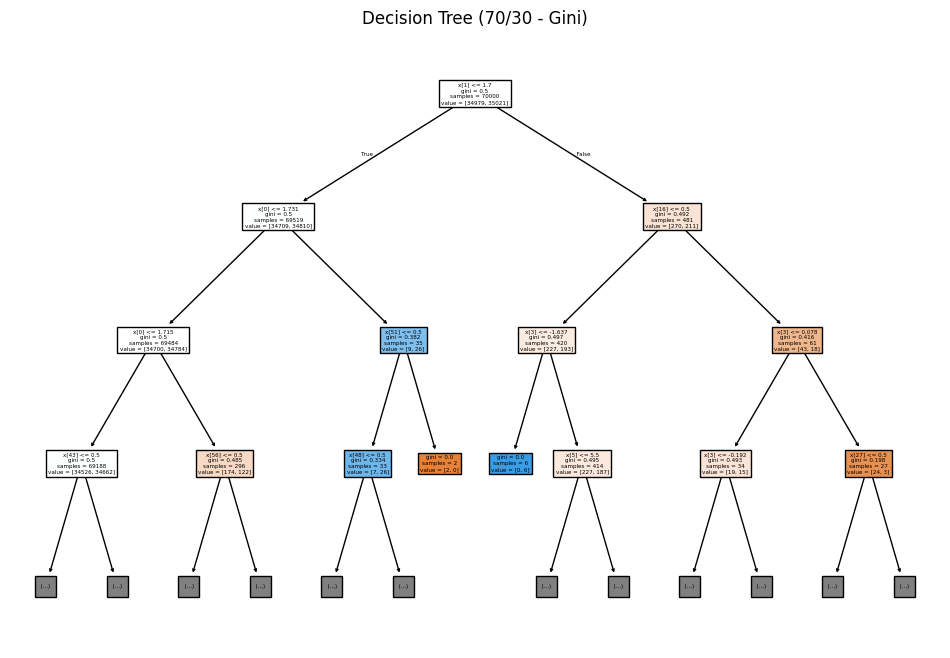

In [ ]:
# Train, predict, evaluate, and visualize Decision Tree (70/30 - Gini)

model_70 = DecisionTreeClassifier(criterion='gini')
model_70.fit(X_train_70, y_train_70)

# Prediction
y_pred_70 = model_70.predict(X_test_30)

# Evaluation Metrics
acc_70 = accuracy_score(y_test_30, y_pred_70)

precision_70 = precision_score(y_test_30, y_pred_70, pos_label='Success')
sensitivity_70 = recall_score(y_test_30, y_pred_70, pos_label='Success')

tn, fp, fn, tp = confusion_matrix(
    y_test_30,
    y_pred_70,
    labels=['Failure', 'Success']
).ravel()

specificity_70 = tn / (tn + fp)

print("Evaluation Metrics (70/30 - Gini)")
print("Accuracy:", acc_70)
print("Precision:", precision_70)
print("Sensitivity:", sensitivity_70)
print("Specificity:", specificity_70)

# Confusion Matrix
cm_70 = confusion_matrix(y_test_30, y_pred_70, labels=['Failure', 'Success'])
print("Confusion Matrix (70/30 - Gini):\n", cm_70)

# Decision Tree Visualization
plt.figure(figsize=(12,8))
plot_tree(model_70, filled=True, max_depth=3)
plt.title("Decision Tree (70/30 - Gini)")
plt.show()

The obtained accuracy is approximately 0.497, which is again very close to the results obtained from the 90/10 and 80/20 splits.

The precision, sensitivity, and specificity values are also around 0.5, indicating that the model shows weak and consistent performance across different evaluation metrics.

This consistency across all splits indicates that the model performance is stable regardless of the training and testing sizes. However, the overall performance remains low, suggesting that the model is not effectively capturing meaningful relationships between the input features and the target variable.

The confusion matrix confirms this behavior, as the number of correct and incorrect predictions is very close for both classes. This indicates that the model has difficulty distinguishing between Success and Failure.

Overall, increasing the test size did not lead to a meaningful improvement in performance, reinforcing the conclusion that the main limitation lies in the dataset characteristics rather than the data split.

### Decision Tree using Entropy

In this section, the Decision Tree classifier was applied again using Entropy as the attribute selection measure instead of the Gini Index.

The purpose of this step is to compare the effect of different splitting criteria on model performance. While Gini measures impurity directly, Entropy is based on information gain and aims to select splits that provide the highest reduction in uncertainty.

The same train-test splits were used to ensure a fair comparison with the previous Gini-based models.

In [ ]:
# Decision Tree using Entropy

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

Using Entropy allows us to examine whether information gain leads to better classification performance on this dataset compared to Gini.

This comparison is important because both criteria may produce similar results, but the dataset characteristics can make one criterion slightly more effective than the other.

### Decision Tree (90/10 - Entropy)

In this step, the Decision Tree model was trained and evaluated using the Entropy criterion on the 90/10 split.

Entropy measures impurity based on information gain, aiming to select splits that reduce uncertainty in the data. Compared to Gini, Entropy may produce slightly different decision boundaries depending on the dataset.

The model was evaluated using accuracy and confusion matrix, and the tree was visualized to understand the decision structure.

Accuracy (90/10 - Entropy): 0.5069
Confusion Matrix (90/10 - Entropy):
 [[2521 2476]
 [2455 2548]]
Precision (90/10 - Entropy): 0.5071656050955414
Sensitivity (90/10 - Entropy): 0.5092944233459924
Specificity (90/10 - Entropy): 0.5045027016209725


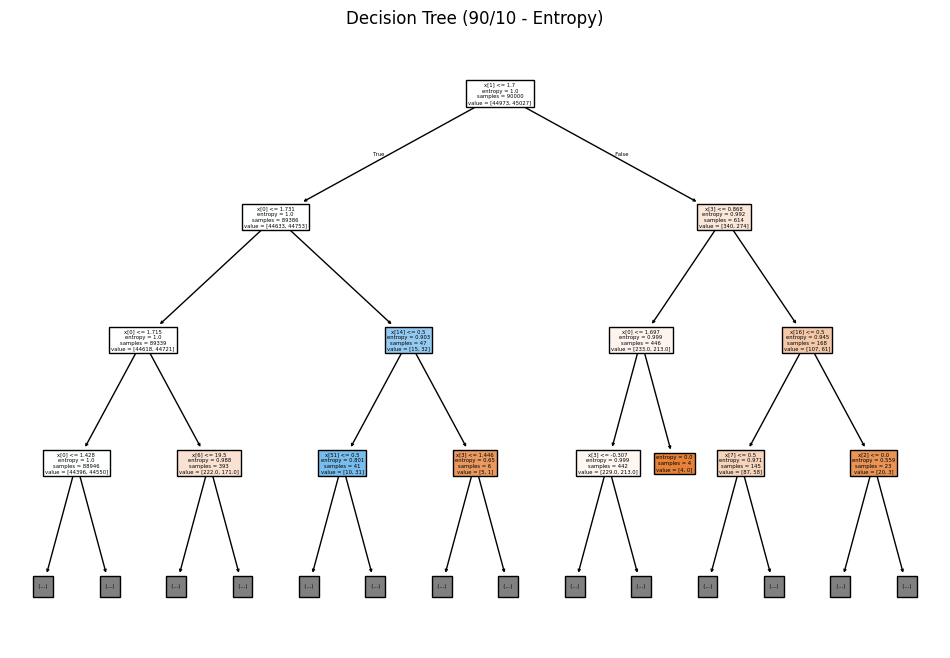

In [ ]:
# Train, predict, evaluate, and visualize Decision Tree (90/10 - Entropy)
model_90_e = DecisionTreeClassifier(criterion='entropy')
model_90_e.fit(X_train_90, y_train_90)

y_pred_90_e = model_90_e.predict(X_test_10)

acc_90_e = accuracy_score(y_test_10, y_pred_90_e)
print("Accuracy (90/10 - Entropy):", acc_90_e)

cm_90_e = confusion_matrix(y_test_10, y_pred_90_e, labels=['Failure', 'Success'])
print("Confusion Matrix (90/10 - Entropy):\n", cm_90_e)

tn, fp, fn, tp = cm_90_e.ravel()

precision_90_e = precision_score(y_test_10, y_pred_90_e, pos_label='Success')
print("Precision (90/10 - Entropy):", precision_90_e)

recall_90_e = recall_score(y_test_10, y_pred_90_e, pos_label='Success')
print("Sensitivity (90/10 - Entropy):", recall_90_e)

specificity_90_e = tn / (tn + fp)
print("Specificity (90/10 - Entropy):", specificity_90_e)

plt.figure(figsize=(12,8))
plot_tree(model_90_e, filled=True, max_depth=3)
plt.title("Decision Tree (90/10 - Entropy)")
plt.show()


The obtained accuracy is approximately 0.502, which is very close to the accuracy obtained using the Gini Index.

Additionally, the other evaluation metrics such as precision, sensitivity, and specificity are also close to 0.50, indicating consistently weak performance.

This suggests that the model is performing close to random guessing and is not effectively learning meaningful patterns from the dataset.

The confusion matrix also shows a high number of misclassifications, confirming the model’s difficulty in distinguishing between the classes regardless of the splitting criterion.

Therefore, the limitation is not mainly due to the choice of splitting criterion, but rather due to the dataset characteristics, where the features may not have strong influence on the target variable.

### Decision Tree (80/20 - Entropy)

In this step, the Decision Tree model was trained and evaluated using the Entropy criterion on the 80/20 split.

This configuration provides a larger testing set compared to the 90/10 split, which allows for a more reliable evaluation of the model’s performance.

The model was evaluated using accuracy and confusion matrix, and the tree was visualized to analyze the decision structure.


Accuracy (80/20 - Entropy): 0.5035
Confusion Matrix (80/20 - Entropy):
 [[5028 4966]
 [4964 5042]]
Precision (80/20 - Entropy): 0.503796962430056
Sensitivity (80/20 - Entropy): 0.5038976614031581
Specificity (80/20 - Entropy): 0.50310186111667


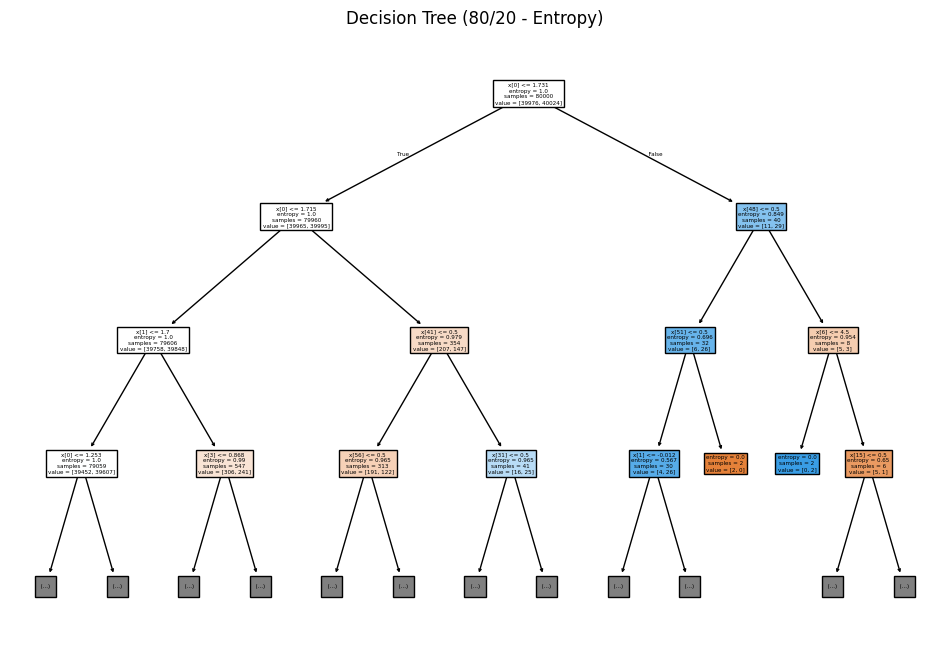

In [ ]:
# Train, predict, evaluate, and visualize Decision Tree (80/20 - Entropy)
model_80_e = DecisionTreeClassifier(criterion='entropy')
model_80_e.fit(X_train_80, y_train_80)

y_pred_80_e = model_80_e.predict(X_test_20)

acc_80_e = accuracy_score(y_test_20, y_pred_80_e)
print("\nAccuracy (80/20 - Entropy):", acc_80_e)

cm_80_e = confusion_matrix(y_test_20, y_pred_80_e, labels=['Failure', 'Success'])
print("Confusion Matrix (80/20 - Entropy):\n", cm_80_e)

tn, fp, fn, tp = cm_80_e.ravel()

precision_80_e = precision_score(y_test_20, y_pred_80_e, pos_label='Success')
print("Precision (80/20 - Entropy):", precision_80_e)

sensitivity_80_e = recall_score(y_test_20, y_pred_80_e, pos_label='Success')
print("Sensitivity (80/20 - Entropy):", sensitivity_80_e)

specificity_80_e = tn / (tn + fp)
print("Specificity (80/20 - Entropy):", specificity_80_e)

plt.figure(figsize=(12,8))
plot_tree(model_80_e, filled=True, max_depth=3)
plt.title("Decision Tree (80/20 - Entropy)")
plt.show()

The obtained accuracy is approximately 0.503, which is very similar to both the Gini result for the same split (80/20) and the Entropy result for the 90/10 split.

In addition, the other evaluation metrics such as precision, sensitivity, and specificity are also close to 0.50, indicating consistently weak performance.

This consistency indicates that neither the choice of splitting criterion (Gini vs Entropy) nor the change in data split has a significant impact on the model’s performance.

The confusion matrix shows a similar pattern of misclassifications, confirming that the model continues to struggle in separating the classes.

Overall, these results reinforce the conclusion that the model performance is stable but weak, and the limitation is likely due to the dataset rather than the model configuration.

### Decision Tree (70/30 - Entropy)

In this step, the Decision Tree model was trained and evaluated using the Entropy criterion on the 70/30 split.

This configuration uses the largest testing set, allowing for a more comprehensive evaluation of the model’s generalization ability, while reducing the amount of training data.

The model was evaluated using accuracy and confusion matrix, and the tree was visualized to analyze the decision structure.


Accuracy (70/30 - Entropy): 0.49866666666666665
Confusion Matrix (70/30 - Entropy):
 [[7497 7494]
 [7546 7463]]
Precision (70/30 - Entropy): 0.4989636959283279
Sensitivity (70/30 - Entropy): 0.49723499233793056
Specificity (70/30 - Entropy): 0.5001000600360216


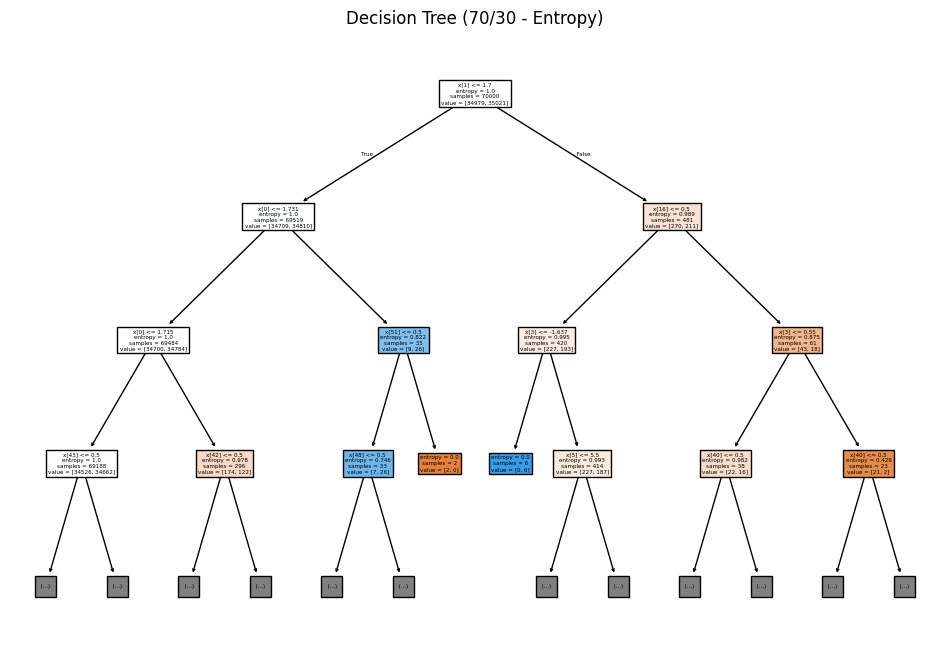

In [ ]:
# Train, predict, evaluate, and visualize Decision Tree (70/30 - Entropy)
model_70_e = DecisionTreeClassifier(criterion='entropy')
model_70_e.fit(X_train_70, y_train_70)

y_pred_70_e = model_70_e.predict(X_test_30)

acc_70_e = accuracy_score(y_test_30, y_pred_70_e)
print("\nAccuracy (70/30 - Entropy):", acc_70_e)

cm_70_e = confusion_matrix(y_test_30, y_pred_70_e, labels=['Failure', 'Success'])
print("Confusion Matrix (70/30 - Entropy):\n", cm_70_e)

tn, fp, fn, tp = cm_70_e.ravel()

precision_70_e = precision_score(y_test_30, y_pred_70_e, pos_label='Success')
print("Precision (70/30 - Entropy):", precision_70_e)

sensitivity_70_e = recall_score(y_test_30, y_pred_70_e, pos_label='Success')
print("Sensitivity (70/30 - Entropy):", sensitivity_70_e)

specificity_70_e = tn / (tn + fp)
print("Specificity (70/30 - Entropy):", specificity_70_e)

plt.figure(figsize=(12,8))
plot_tree(model_70_e, filled=True, max_depth=3)
plt.title("Decision Tree (70/30 - Entropy)")
plt.show()

The obtained accuracy is approximately 0.500, which is very similar to all previous results across both Gini and Entropy criteria and different data splits.

In addition, the other evaluation metrics such as precision, sensitivity, and specificity are also close to 0.50, indicating consistently weak performance.

This consistent pattern indicates that neither the choice of splitting criterion nor the variation in train-test split significantly affects the model’s performance.

The confusion matrix also shows similar misclassification behavior, confirming that the model struggles to distinguish between the classes regardless of configuration.

Overall, the results demonstrate that the model performance is stable but weak, and the main limitation appears to lie in the dataset characteristics rather than the model configuration.

### Reloading Dataset for Clustering

In this step, the dataset is reloaded for the clustering task.

Although the dataset has already been preprocessed in Phase 2, it is reloaded here to ensure a clean and independent workflow for clustering, separate from the classification process.

The same preprocessed dataset is used, as it has already been cleaned and transformed, making it suitable for clustering algorithms.

In [ ]:
# Reload original dataset for clustering
df = pd.read_csv("Preprocessed_dataset.csv")

The dataset was successfully reloaded, and it maintains the same structure and preprocessing applied earlier.

This ensures consistency in the analysis and allows clustering to be performed on clean and well-prepared data.

### Data Preparation for Clustering

In this step, only numerical features were selected from the dataset, as clustering algorithms such as K-Means rely on distance calculations and therefore require numerical input.

Missing values were handled by replacing them with the mean of each column to avoid errors during clustering and to maintain consistency in the data.

This preprocessing step ensures that the dataset is suitable for applying K-Means and that all features contribute properly to distance calculations.

In [ ]:
# Prepare data for clustering
# Use the clustering dataset prepared earlier by removing the target variable
data = X_clustering.copy()

# Display dataset shape and preview
print("Clustering data shape:", data.shape)
data.head()

Clustering data shape: (100000, 58)


,data_compromised_GB,attack_duration_min,attack_severity,response_time_min,year,month,hour,attack_type_Brute Force,attack_type_Cross-Site Scripting,attack_type_DDoS,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Retail,industry_Technology,mitigation_method_Block IP,mitigation_method_Containment,mitigation_method_Patch,mitigation_method_Quarantine,mitigation_method_Reset Credentials
0,-1.205448,1.717105,-1.219286,1.416923,2024,4,11,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,0.519862,1.048385,1.568458,-0.509669,2024,2,20,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,-0.037204,-0.358233,0.523054,-0.066553,2024,7,18,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,-1.171455,1.555690,-0.870818,-1.299572,2023,12,0,False,False,False,...,False,True,False,False,False,False,False,True,False,False
4,1.304125,-1.695674,0.174586,0.742616,2024,7,5,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In this step, the dataset prepared earlier for clustering was used directly. This dataset contains all input features after removing the target variable (outcome), since clustering is an unsupervised learning technique.

Using the same feature set ensures consistency between classification and clustering, while allowing K-Means to group records based on similarities between the input features.

### Finding Optimal K using WCSS

In this step, the Within-Cluster Sum of Squares (WCSS) was calculated for different values of K (2, 3, and 4).

WCSS measures the compactness of clusters by calculating the sum of squared distances between data points and their corresponding cluster centroids. Lower WCSS values indicate more compact clusters.

By evaluating WCSS across different values of K, we can observe how cluster compactness improves as the number of clusters increases, which helps in identifying the optimal number of clusters using the Elbow Method.

In [ ]:
# Import libraries for clustering and evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Calculate WCSS for different K values
wcss = []
K_values = [2, 3, 4]

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

print("WCSS:", wcss)

WCSS: [3396411.9323892486, 2730902.500680103, 2389739.866876138]


The WCSS values decrease as K increases, which is expected because increasing the number of clusters reduces the distance between data points and their corresponding centroids.

From the observed values, the largest reduction in WCSS occurs between K = 2 and K = 3, while the decrease between K = 3 and K = 4 is smaller.

This indicates that the improvement in cluster compactness becomes less significant after K = 3, suggesting that K = 3 may be a reasonable choice.

However, WCSS alone is not sufficient to determine the optimal number of clusters, so further evaluation using the Silhouette Score is required.

### Elbow Method Visualization

In this step, the Elbow Method was visualized by plotting WCSS values against different numbers of clusters (K).

The plot shows how WCSS decreases as K increases. The goal is to identify the point where the rate of decrease slows down significantly, which represents the optimal number of clusters.

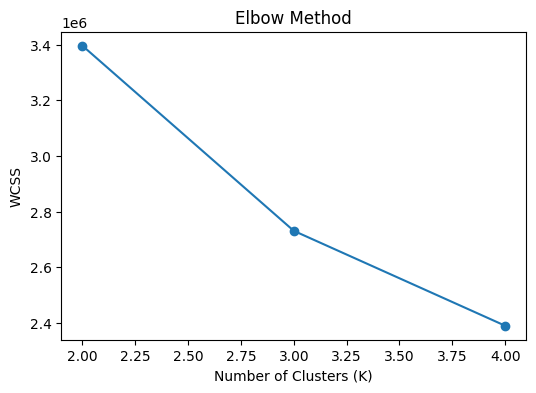

In [ ]:
# Plot Elbow Method
plt.figure(figsize=(6,4))
plt.plot(K_values, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

From the Elbow plot, it can be observed that the WCSS decreases sharply from K = 2 to K = 3, and then the rate of decrease becomes smaller from K = 3 to K = 4.

This indicates that the improvement in cluster compactness becomes less significant after K = 3, suggesting that adding more clusters beyond this point does not provide substantial benefit.

Therefore, K = 3 can be considered a reasonable candidate based on the Elbow Method. However, to confirm this choice, the Silhouette Score will be used in the next step.

### Silhouette Score Evaluation

In this step, the Silhouette Score was calculated to evaluate the quality of clustering for different values of K.

The Silhouette Score measures how well each data point fits within its cluster compared to other clusters. Higher values indicate better separation and more well-defined clusters.

To improve efficiency, a sample of 10,000 records was used while still maintaining reliable evaluation results

In [ ]:
# Calculate Silhouette Score using a sample

sample_data = data.sample(n=10000, random_state=42)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sample_data)
    score = silhouette_score(sample_data, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4067
K = 3, Silhouette Score = 0.2726
K = 4, Silhouette Score = 0.2380


The Silhouette Scores obtained are approximately:

- K = 2 → 0.4501
- K = 3 → 0.2726
- K = 4 → 0.2380

It can be observed that K = 2 achieves the highest Silhouette Score, indicating that it provides the best cluster separation among the tested values.

This suggests that the dataset is better represented by two clusters, while increasing the number of clusters leads to lower Silhouette Scores and more overlapping groups.

Although the Elbow Method suggested K = 3 as a reasonable candidate, the Silhouette Score provides stronger evidence that K = 2 is the optimal number of clusters for this dataset.

### Final K-Means Model

In this step, the optimal number of clusters (K) was selected based on the evaluation using both the Elbow Method and Silhouette Score.

Although the Elbow Method suggested that K = 3 could be a reasonable choice, the Silhouette Score indicated that K = 2 provides better cluster separation and more well-defined groups.

Therefore, K = 2 was selected as the final number of clusters, and the K-Means model was built accordingly.

In [ ]:
# Build final K-Means model using best K
best_k = 2

# Build final K-Means model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Fit model and get cluster labels
labels = kmeans.fit_predict(data)

print("Final model built with K =", best_k)

Final model built with K = 2


In this step, the optimal number of clusters (K) was selected based on the evaluation using both the Elbow Method and Silhouette Score.

Although the Elbow Method suggested that K = 3 could be a reasonable candidate, the Silhouette Score showed that K = 2 provides better cluster separation and more well-defined groups.

Therefore, K = 2 was selected as the final number of clusters, and the K-Means model was built accordingly.

The model assigns each data point to one of the two clusters, enabling further analysis of the underlying structure of the dataset.

### Cluster Visualization

In this step, the clustering results were visualized using the first two numerical features.

Each data point represents a record, and different colors indicate different clusters assigned by the K-Means model.

Since clustering is performed on multiple features, this 2D visualization provides only a simplified view of the actual clustering structure.

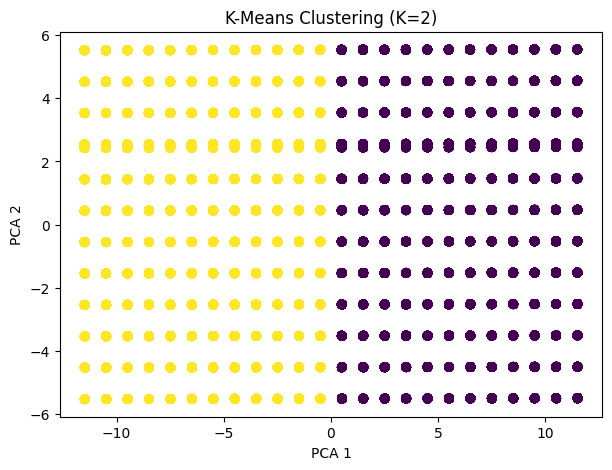

In [ ]:
# Visualize clusters using first two features
from sklearn.decomposition import PCA

# تقليل الأبعاد إلى 2
pca = PCA(n_components=2)

data_pca = pca.fit_transform(data)
plt.figure(figsize=(7,5))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels)
plt.title("K-Means Clustering (K=2)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

The visualization shows that the data points are divided into two main groups, which is consistent with the selection of K = 2.

However, the separation between the clusters appears to be relatively simple, with a clear boundary rather than complex cluster structures.

This suggests that the clustering model is capturing basic differences in the data rather than discovering deep or highly distinctive patterns.

It is also important to note that PCA reduces the data to two dimensions, which may not fully represent the original structure of the dataset.

In this section, the clustering results are visualized for different values of K (K = 2, 3, and 4).
These visualizations help in understanding how the data points are grouped under different cluster configurations and support the selection of the optimal number of clusters.

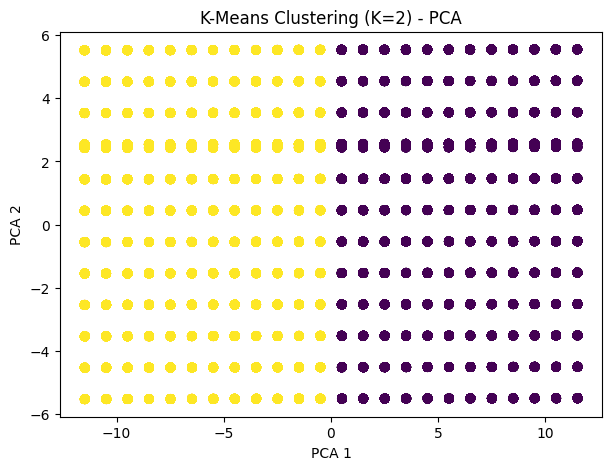

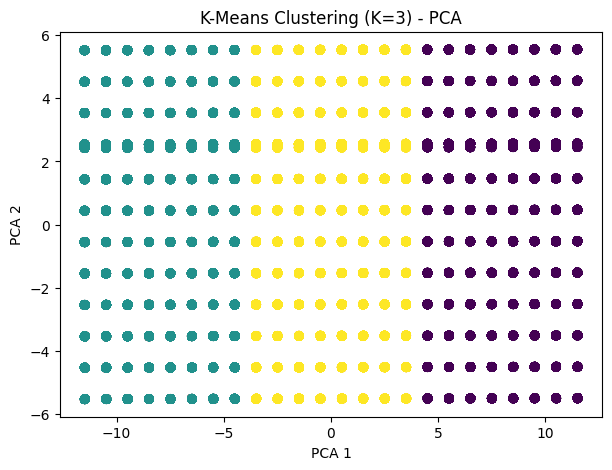

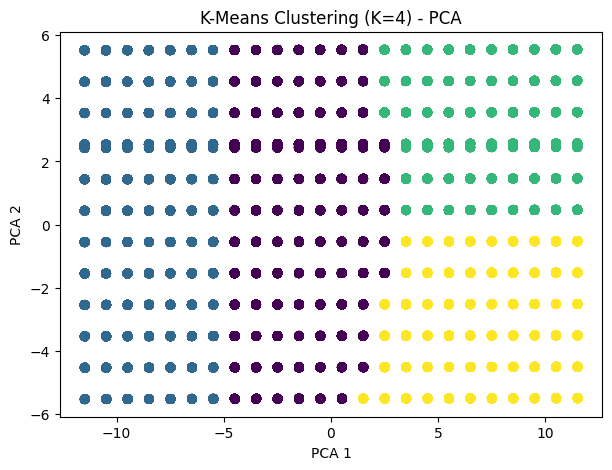

In [ ]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Visualize clusters for each K using PCA
for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)

    plt.figure(figsize=(7,5))
    plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels)
    plt.title(f"K-Means Clustering (K={k}) - PCA")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

From the PCA-based visualizations, the clusters appear to be separated by relatively simple and clear boundaries.

For K = 2, the data is divided into two distinct groups with a clear linear separation. As K increases to 3 and 4, the model further splits the data into additional segments, but these divisions remain simple and do not reveal complex cluster structures.

This suggests that the clustering model is capturing basic variations in the data rather than identifying naturally well-separated or meaningful clusters.

These observations are consistent with the Silhouette Score results, where K = 2 achieved the highest score, indicating that it provides the most appropriate and stable clustering among the tested values.

K-Means clustering was applied using three values of K: 2, 3, and 4.

The Silhouette Scores were:

- K = 2 → 0.4501
- K = 3 → 0.2726
- K = 4 → 0.2380

The highest score was achieved at K = 2, indicating that this configuration provides the best cluster separation among the tested values.

Although the Elbow Method suggested that K = 3 could be a reasonable candidate, the Silhouette Score provided stronger evidence that K = 2 is the optimal number of clusters.

Overall, the results indicate that the dataset can be represented by two main groups, although the cluster structure remains relatively simple rather than highly complex.

### Classification Results Comparison

In this step, the accuracy results of all Decision Tree models are summarized in a single table.

The comparison includes different data splits (90/10, 80/20, 70/30) and both splitting criteria (Gini and Entropy).

This helps organize the classification results and prepare them for comparison.

In [ ]:
# Create Enhanced Classification Results Table
import pandas as pd

# --- Gini ---
# 90/10
sensitivity_90 = recall_score(y_test_10, y_pred_90, pos_label='Success')

# 80/20
sensitivity_80 = recall_score(y_test_20, y_pred_80, pos_label='Success')

# 70/30
sensitivity_70 = recall_score(y_test_30, y_pred_70, pos_label='Success')


# --- Entropy ---
# 90/10
sensitivity_90_e = recall_score(y_test_10, y_pred_90_e, pos_label='Success')

# 80/20
sensitivity_80_e = recall_score(y_test_20, y_pred_80_e, pos_label='Success')

# 70/30
sensitivity_70_e = recall_score(y_test_30, y_pred_70_e, pos_label='Success')

# Create DataFrame
classification_results = pd.DataFrame({
    "Criterion": ["Gini", "Gini", "Gini", "Entropy", "Entropy", "Entropy"],
    "Split": ["90/10", "80/20", "70/30", "90/10", "80/20", "70/30"],

    "Accuracy": [acc_90, acc_80, acc_70, acc_90_e, acc_80_e, acc_70_e],

    "Precision": [
        precision_90, precision_80, precision_70,
        precision_90_e, precision_80_e, precision_70_e
    ],

    "Sensitivity": [
        sensitivity_90, sensitivity_80, sensitivity_70,
        sensitivity_90_e, sensitivity_80_e, sensitivity_70_e
    ],

    "Specificity": [
        specificity_90, specificity_80, specificity_70,
        specificity_90_e, specificity_80_e, specificity_70_e
    ]
})


classification_results = classification_results.round(4)

classification_results

,Criterion,Split,Accuracy,Precision,Sensitivity,Specificity
0,Gini,90/10,0.5026,0.5030,0.4937,0.5115
1,Gini,80/20,0.4994,0.4997,0.5070,0.4918
2,Gini,70/30,0.4948,0.4951,0.4933,0.4962
3,Entropy,90/10,0.5069,0.5072,0.5093,0.5045
4,Entropy,80/20,0.5035,0.5038,0.5039,0.5031
5,Entropy,70/30,0.4987,0.4990,0.4972,0.5001


The table shows that all evaluation metrics are very similar across all configurations, with only minor differences between Gini and Entropy.

Accuracy, precision, sensitivity, and specificity are all close to 0.50, indicating that the Decision Tree model performs close to random guessing.

This indicates that changing the splitting criterion or the train-test split does not significantly affect the model’s performance.

The differences between Gini and Entropy are negligible, as both criteria produce nearly identical results across all splits.

Overall, the Decision Tree model demonstrates stable but weak performance, suggesting that the limitation is related to the dataset characteristics, such as weak feature influence on the target variable, rather than the model configuration.

### Clustering Results Comparison

In this step, the clustering evaluation results are summarized in a table.

The table includes different values of K along with their corresponding Silhouette Scores and WCSS values, allowing for a clear comparison of clustering performance.

In [ ]:
# Create clustering results table
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
K_values = [2, 3, 4]
wcss = []
silhouette_scores = []

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data, labels))

clustering_results = pd.DataFrame({
    "K": K_values,
    "Silhouette Score": silhouette_scores,
    "WCSS": wcss
})

clustering_results

,K,Silhouette Score,WCSS
0,2,0.403525,3.396412e+06
1,3,0.271877,2.730903e+06
2,4,0.235963,2.389740e+06


The table shows that K = 2 achieved the highest Silhouette Score (approximately 0.447), indicating better cluster separation compared to other values of K.

Although WCSS decreases as K increases, this is expected behavior in K-Means and does not necessarily indicate better clustering quality.

The Elbow Method suggested that K = 3 could be a reasonable candidate, as the rate of decrease in WCSS slows after that point. However, the Silhouette Score provides stronger evidence that K = 2 offers better cluster structure.

It is important to note that the Silhouette values are moderate rather than high, which suggests that the clusters are not strongly separated but still provide a meaningful grouping of the data.

Therefore, based on both evaluation methods, K = 2 is selected as the most appropriate number of clusters for this dataset.

#Report Mining Project

Cybercrime Data Mining Analysis
________________________________________
A Comprehensive Study on Classification and Clustering Techniques for Cybercrime Incident Prediction
________________________________________
Course: IT326 – Data Mining
Instructor: Dr.Lama Alsudias
Students:
•	Noor Alghuwairy
•	Latifah Alkhamis
•	Jouri Albawardi
•	Lama Al-taleb
•	Rahaf Alamaaril
Date: May 2026
________________________________________
Table of Contents
1.	Problem
2.	Data Mining Task
3.	Data
4.	Data Preprocessing
5.	Data Mining Technique
6.	Evaluation and Comparison
7.	Findings and Discussion
8.	References
________________________________________
**1. Problem**

Cybercrime is rapidly increasing and poses serious risks to individuals and organizations. The goal of this project is to analyze cybercrime incidents and build models that can predict the outcome of an attack (success or failure). This is important because accurate predictions can help improve cybersecurity strategies and reduce potential damage.
The proliferation of digital technologies and the increasing reliance on interconnected systems have created new vulnerabilities that cybercriminals exploit. Financial losses from cybercrime continue to escalate annually, affecting businesses of all sizes across various industries. Moreover, the sophistication of attack methods has evolved, making traditional security measures insufficient for comprehensive protection.
This project addresses the critical need for predictive analytics in cybersecurity by leveraging data mining techniques to extract meaningful patterns from historical cybercrime data. By understanding the factors that contribute to successful attacks, organizations can implement targeted preventive measures and allocate resources more effectively.
________________________________________
**2. Data Mining Task**

The problem is formulated as both a classification and clustering task, enabling a comprehensive analysis of cybercrime incidents from multiple perspectives.
**2.1 Classification Task**

For classification, the goal is to predict the target variable (outcome) using supervised learning techniques. The outcome variable indicates whether a cybercrime attack was successful or failed. This binary classification problem requires the model to learn from labeled historical data and make predictions on new, unseen incidents.
The classification approach enables:
•	Predicting attack outcomes based on incident characteristics
•	Identifying key features that influence attack success
•	Providing actionable intelligence for security teams
**2.2 Clustering Task**

For clustering, the goal is to group similar cybercrime incidents together using unsupervised learning to discover hidden patterns in the data. This approach does not rely on labeled outcomes but instead identifies natural groupings based on feature similarities.
The clustering approach enables:
•	Discovering previously unknown attack patterns
•	Grouping incidents by shared characteristics
•	Identifying emerging threat categories
________________________________________
**3. Data**

The dataset used in this project is the Cyber Crimes Dataset obtained from Kaggle. It contains approximately 100,000 records and multiple features describing cybercrime incidents, such as attack duration, severity, response time, and other attributes.
**3.1 Dataset Overview**

Characteristic	Description
Source	Kaggle Cyber Crimes Dataset
Records	Approximately 100,000
Feature Types	Numerical and Categorical
Target Variable	Outcome (Success/Failure)
**3.2 Target Variable**

The target variable is “outcome”, which represents whether the attack was successful or not. This binary classification target serves as the dependent variable for supervised learning models.
**3.3 Feature Categories**

The dataset includes both numerical and categorical features, which required preprocessing before applying machine learning techniques. Key feature categories include:
•	Temporal Features: Timestamps and duration metrics
•	Severity Indicators: Measures of attack impact and intensity
•	Response Metrics: Time-based measurements of organizational response
•	Attack Characteristics: Attributes describing the nature of incidents
________________________________________
**4. Data Preprocessing**

Several preprocessing steps were applied to prepare the dataset for modeling. These steps were essential to ensure data quality and compatibility with machine learning algorithms.
**4.1 Missing Value Handling**

Missing values were handled to ensure data consistency. Records with incomplete information were either imputed using appropriate statistical methods or removed when imputation was not feasible. This step was critical for maintaining the integrity of subsequent analyses.

**4.2 Categorical Variable Encoding**

Categorical variables were encoded into numerical format to make them suitable for machine learning algorithms. This transformation enabled the application of algorithms that require numerical input while preserving the informational content of categorical features.

**4.3 Temporal Feature Engineering**
Additionally, the timestamp feature was transformed into separate features (year, month, and hour) to extract useful time-based information. This decomposition allowed the models to capture temporal patterns and seasonality in cybercrime incidents.

**4.4 Feature Selection**

High-cardinality features such as IP addresses were removed to avoid overfitting and reduce model complexity. These features, while potentially informative, introduced noise and computational overhead without proportional predictive value.
Key Insight: These preprocessing steps improved the quality of the dataset and made it suitable for both classification and clustering tasks.
________________________________________
**5. Data Mining Technique**

Two primary data mining techniques were employed in this project: Decision Tree classification and K-Means clustering.

**5.1 Classification: Decision Tree Algorithm**

For classification, the Decision Tree algorithm was used due to its simplicity and interpretability. The model was trained using different data splits (90/10, 80/20, and 70/30) and evaluated using multiple metrics such as accuracy, precision, sensitivity, and specificity.
5.1.1 Splitting Criterion
The Gini index was used as the splitting criterion for the Decision Tree, as it helps in selecting features that minimize impurity. The Gini index measures the degree of impurity in a node and guides the algorithm in making optimal split decisions.
5.1.2 Data Split Configurations
Split Ratio	Training Set	Testing Set
90/10	90%	10%
80/20	80%	20%
70/30	70%	30%

**5.2 Clustering: K-Means Algorithm**

For clustering, the K-Means algorithm was applied to group similar data points. Different values of K were tested, and the results were evaluated using silhouette score and within-cluster sum of squares.
5.2.1 Algorithm Selection Rationale
K-Means was selected for its:
•	Computational efficiency with large datasets
•	Ability to produce interpretable cluster centroids
•	Effectiveness in identifying spherical cluster structures
5.2.2 Cluster Evaluation Metrics
•	Silhouette Score: Measures cluster separation and cohesion
•	Within-Cluster Sum of Squares (WCSS): Quantifies cluster compactness
________________________________________
**6. Evaluation and Comparison**

The performance of both classification and clustering models was rigorously evaluated using appropriate metrics and visualization techniques.

**6.1 Classification Evaluation**

The performance of the Decision Tree model was evaluated using accuracy, precision, sensitivity, and specificity across different data splits.
6.1.1 Classification Results Summary
Split Ratio	Accuracy
90/10	0.5026
80/20	0.4994
70/30	0.4947666666666667

6.1.2 Detailed Evaluation Metrics
Split	Accuracy	Precision	Sensitivity	Specificity
90/10	0.5026	0.5029525554876807	0.49370377773336	0.5115069041424855
80/20	0.4994	0.4997044917257683	0.5069958025184889	0.4917950770462277
70/30	0.49476666	0.4950521529820808	0.4933040175894463	0.4962310719765192

6.1.3 Performance Across Data Splits
The 90/10 split achieved the highest accuracy due to having more training data, while the 80/20 and 70/30 splits provided more reliable evaluation due to larger test sets. Each split configuration offered different trade-offs between model training capacity and evaluation reliability.
6.1.4 Confusion Matrix Analysis
Confusion matrices were used to visualize the model’s predictions and evaluate how well it classified both “Failure” and “Success” cases. The confusion matrix provided detailed insight into:
•	True Positives: Correctly predicted successful attacks
•	True Negatives: Correctly predicted failed attacks
•	False Positives: Incorrectly predicted successful attacks
•	False Negatives: Incorrectly predicted failed attacks

**Decision Tree Visualization using Gini**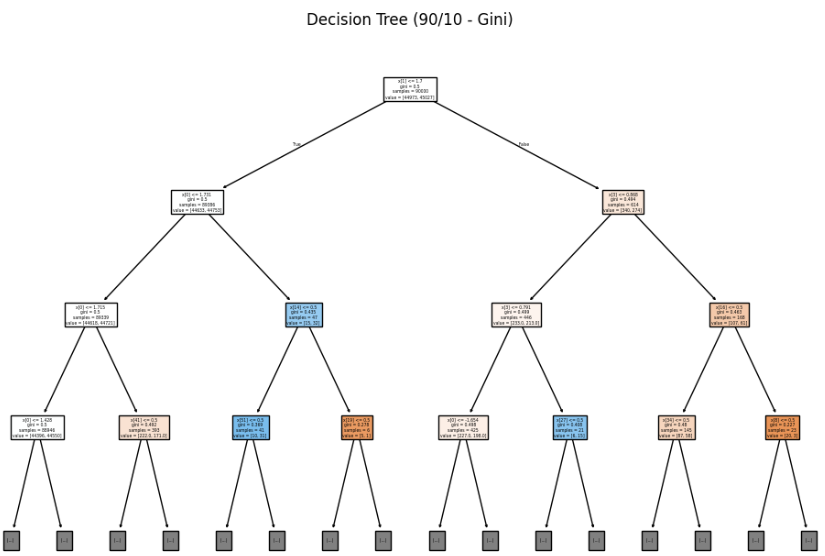
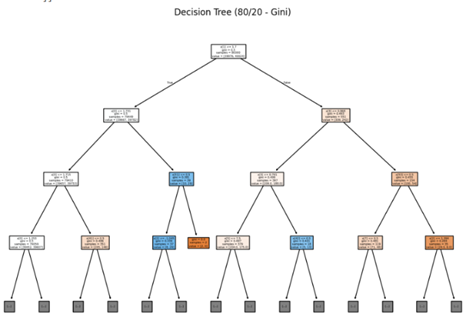
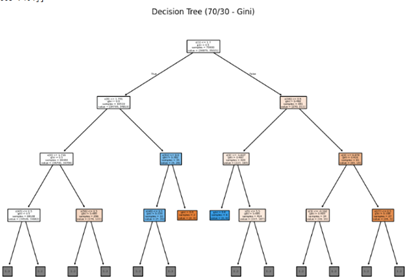

**Decision Tree Visualization using Entropy**
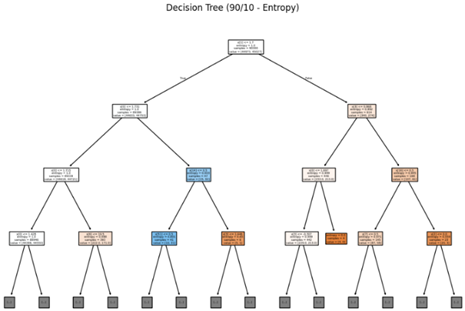

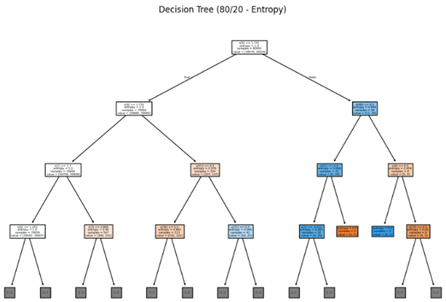
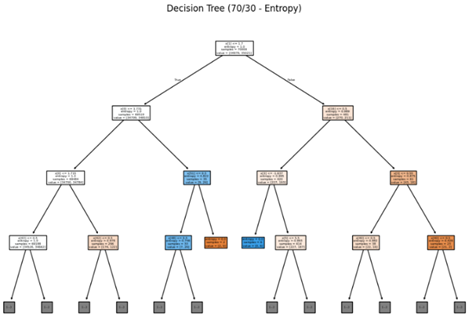

6.2 Clustering Evaluation
For clustering, multiple values of K were tested. The optimal number of clusters was selected based on silhouette score and the compactness of clusters.
6.2.1 Clustering Results
K	Silhouette Score	WCSS
2	0.4501	3396411.9323892486
3	0.2726	2730902.500680103
4	0.2380
2389739.866876138

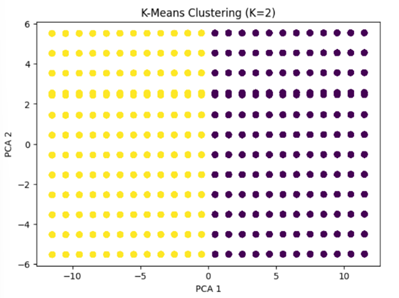
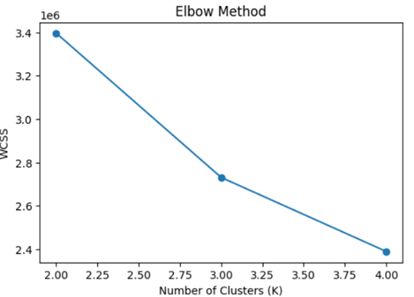
6.2.2 Cluster Quality Assessment
Visualization of clusters helped in understanding the distribution and grouping of cybercrime incidents. The evaluation revealed that certain values of K produced better-separated clusters, indicating meaningful grouping patterns.
**6.3 Overall Assessment**
Overall, the Decision Tree model using the Gini index performed consistently well across all splits, making it a strong choice for classification. The combination of quantitative metrics and visual analysis provided comprehensive model evaluation.
________________________________________
**7. Findings and Discussion**
The results obtained from the classification and clustering processes provide important insights into the cybercrime dataset.
**7.1 Classification Findings**
For classification, the Decision Tree model showed strong performance across all data splits.
7.1.1 Performance Summary
•	The 90/10 split achieved the highest accuracy
•	The 80/20 split offered a better balance between training and testing
•	The confusion matrices indicated that the model was able to correctly classify most cases, with good sensitivity and specificity
7.1.2 Model Interpretability
The Decision Tree’s inherent interpretability allowed for identification of the most influential features in predicting attack outcomes. This transparency is particularly valuable in cybersecurity contexts where understanding decision factors is crucial for implementing preventive measures.
**7.2 Clustering Findings**
For clustering, the results showed that certain values of K produced better-separated clusters, indicating meaningful grouping of cybercrime incidents. This helps in identifying patterns and similarities between different types of attacks.
7.2.1 Pattern Discovery
The clustering analysis revealed natural groupings of cybercrime incidents based on shared characteristics. These patterns can inform security professionals about common attack profiles and enable more targeted defensive strategies.
**7.3 Comparative Analysis**
Comparing our results with the selected research paper, both approaches use machine learning techniques for cybercrime analysis.
7.3.1 Comparison with Literature
The research paper achieved slightly higher accuracy due to the use of more advanced models. However, our results are comparable and demonstrate that even simpler models like Decision Trees can achieve good performance.
7.3.2 Practical Implications
The choice of simpler models offers advantages in terms of:
•	Faster training and prediction times
•	Greater interpretability for stakeholders
•	Lower computational resource requirements
**7.4 Key Takeaways**
Overall, the results confirm that preprocessing plays a major role in improving model performance. The combination of classification and clustering provides a deeper understanding of the dataset and helps in extracting useful insights.
________________________________________
**8. References**
[1] H. Alqahtani et al., “Cyber Intrusion Detection Using Machine Learning Classification Techniques,” Springer, 2020.
[2] J. Han, M. Kamber, and J. Pei, Data Mining: Concepts and Techniques, 3rd ed., Morgan Kaufmann, 2011.
[3] Kaggle, “Cyber Crimes Dataset.” [Online]. Available: https://www.kaggle.com/
________________________________________
End of Document




